# InternVL3.5-4B 문서 이해 예제

[InternVL3.5-4B-HF](https://huggingface.co/OpenGVLab/InternVL3_5-4B-HF)는 OpenGVLab의 **비전-언어 모델(VLM)** 로, Qwen3 기반 LLM + InternViT-300M 비전 인코더를 사용합니다.
OCRBench 등 문서·텍스트 인식 벤치마크에서 강한 성능을 보이며, **한국어 OCR·표 추출·문서 요약**에 활용할 수 있습니다.

논문: [InternVL3.5: Advancing Open-Source Multimodal Models](https://huggingface.co/papers/2508.18265)

이 노트북에서 다루는 내용:
1. `OpenGVLab/InternVL3_5-4B-HF` 모델 로드 (transformers 5.x 호환 HF 포맷)
2. **이미지 OCR** — 이미지 속 텍스트 전체 추출
3. **표 추출** — Markdown 표 형식으로 구조화
4. **문서 요약** — 문서 유형·핵심 내용·키워드 정리
5. **영수증 분석** — JSON 구조로 항목·금액 파싱

> GitHub 포맷(`InternVL3_5-4B`)은 transformers 5.x에서 `all_tied_weights_keys` 오류가 날 수 있어, 이 노트북은 **HF 포맷**을 사용합니다.



## 1. 환경 설정

터미널에서 의존성을 설치합니다.

```bash
pip install -r requirements.txt
```

InternVL3.5 HF 포맷은 **transformers 4.52.1 이상**(권장: 5.x)과 **`timm`** 이 필요합니다.

```
torch>=2.0.0
transformers>=4.57.0
accelerate>=0.27.0
einops>=0.8.0
timm>=1.0.0
pillow>=10.0.0
matplotlib>=3.8.0
requests>=2.31.0
```

> **GPU 메모리 안내**: `InternVL3_5-4B-HF`는 bf16/fp16 기준 약 **10~12GB VRAM**이면 추론 가능합니다 (RTX 3060 12GB 적합).
> 최초 실행 시 Hugging Face Hub에서 약 **9GB**를 다운로드합니다.
> Flash Attention(`use_flash_attn=True`)은 GPU·패키지 미설치 시 자동으로 비활성화됩니다.


In [2]:
# InternVL3.5 추론에 필요한 패키지 (Colab/신규 환경용 — 최초 1회 실행)
# %pip install -q "transformers>=4.52.1" "accelerate>=0.27.0"
# InternVL 비전 인코더·텐서 reshape에 필요한 패키지 (미설치 시 모델 로드 실패)
%pip install -q einops timm accelerate>=0.27.0


In [3]:
# --- 표준 라이브러리 ---
import json
from io import BytesIO
from pathlib import Path

# --- 시각화·수치·HTTP·딥러닝 ---
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from transformers import AutoModelForImageTextToText, AutoProcessor


def setup_korean_font():
    """matplotlib 한글 폰트 설정 (Windows/Mac/Linux)"""
    # OS별 한글 폰트 후보를 순서대로 탐색
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    else:
        print("한글 폰트를 찾지 못했습니다. 제목 한글이 □로 표시될 수 있습니다.")
    # 음수 기호 깨짐 방지
    plt.rcParams["axes.unicode_minus"] = False


setup_korean_font()

# GPU 사용 가능 여부에 따라 연산 디바이스 결정
device = "cuda" if torch.cuda.is_available() else "cpu"
# Ampere 이상 GPU는 bf16, 그 외 CUDA는 fp16, CPU는 fp32
if device == "cuda" and torch.cuda.is_bf16_supported():
    dtype = torch.bfloat16
else:
    dtype = torch.float16 if device == "cuda" else torch.float32

print(f"사용 디바이스: {device}")
print(f"연산 dtype: {dtype}")
print(f"matplotlib 폰트: {plt.rcParams['font.family']}")


한글 폰트를 찾지 못했습니다. 제목 한글이 □로 표시될 수 있습니다.
사용 디바이스: cuda
연산 dtype: torch.bfloat16
matplotlib 폰트: ['sans-serif']


In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 한글 폰트 설치 (Colab 환경)
!apt-get -qq -y install fonts-nanum > /dev/null

# 2. matplotlib에 폰트 추가 및 캐시 업데이트
fe = fm.FontEntry(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic'
)
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic'})

# 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트(NanumGothic) 설정이 완료되었습니다.")

한글 폰트(NanumGothic) 설정이 완료되었습니다.


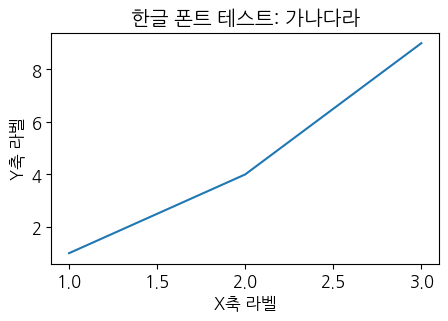

In [16]:
# 설정 확인을 위한 테스트 플롯
plt.figure(figsize=(5, 3))
plt.title("한글 폰트 테스트: 가나다라")
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel("X축 라벨")
plt.ylabel("Y축 라벨")
plt.show()

## 2. InternVL3.5-4B-HF 모델 로드

| 모델 | 포맷 | 특징 |
|------|------|------|
| `OpenGVLab/InternVL3_5-4B-HF` | HF | **이 노트북 기본값** — transformers 5.x 호환 |
| `OpenGVLab/InternVL3_5-4B` | GitHub | `model.chat()` API, transformers 4.x 권장 |
| `OpenGVLab/InternVL3_5-4B-Instruct` | GitHub | SFT만 적용 (RL 없음) |

HF 포맷은 `AutoProcessor` + `apply_chat_template()`으로 Qwen3-VL과 유사하게 추론합니다.


In [4]:
# HuggingFace HF 포맷 — transformers 5.x 호환
MODEL_ID = "OpenGVLab/InternVL3_5-4B-HF"

# from_pretrained()에 전달할 공통 인자
load_kwargs = {
    "dtype": dtype,
    "low_cpu_mem_usage": True,
}

try:
    import accelerate  # noqa: F401
    # GPU VRAM에 맞게 자동 배치
    load_kwargs["device_map"] = "auto"
except ImportError:
    print("accelerate 미설치: device_map 대신 model.to(device)를 사용합니다.")

model = None
# Flash Attention 우선 시도 → 실패 시 일반 attention으로 재시도
for use_flash_attn in (True, False):
    try:
        model = AutoModelForImageTextToText.from_pretrained(
            MODEL_ID,
            use_flash_attn=use_flash_attn,
            **load_kwargs,
        ).eval()
        if not use_flash_attn:
            print("Flash Attention 미사용으로 모델을 로드했습니다.")
        break
    except TypeError:
        if use_flash_attn:
            continue
        model = AutoModelForImageTextToText.from_pretrained(MODEL_ID, **load_kwargs).eval()
        print("Flash Attention 미사용으로 모델을 로드했습니다.")
        break
    except Exception as exc:
        if use_flash_attn:
            print(f"Flash Attention 로드 실패 ({exc}), use_flash_attn=False로 재시도합니다.")
            continue
        raise exc

if "device_map" not in load_kwargs:
    model = model.to(device)

# 이미지·텍스트 전처리 및 chat template 적용용 Processor
processor = AutoProcessor.from_pretrained(MODEL_ID)

model_device = next(model.parameters()).device
print(f"모델 로드 완료: {MODEL_ID}")
print(f"모델 디바이스: {model_device}")
# 모델 다운로드 시간 : 약 20분(9.47G)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/3.00k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/79.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/841 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/913 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

모델 로드 완료: OpenGVLab/InternVL3_5-4B-HF
모델 디바이스: cuda:0


## 3. 추론 헬퍼

`AutoProcessor.apply_chat_template()`으로 InternVL 대화 형식을 맞추고, 입력 토큰 길이만큼 잘라 **assistant 응답만** 디코딩합니다.
이미지 전처리(동적 해상도)는 Processor가 자동으로 처리합니다.


In [7]:
# URL 이미지 재요청 방지용 메모리 캐시
_url_image_cache: dict[str, Image.Image] = {}


def load_image_from_url(url: str) -> Image.Image:
    if url in _url_image_cache:
        return _url_image_cache[url].copy()
    headers = {"User-Agent": "InternVL35-Example-Notebook/1.0 (learning example)"}
    response = requests.get(url, timeout=30, headers=headers)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    _url_image_cache[url] = image
    return image.copy()


def show_image(image: Image.Image, title: str = ""):
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=11)
    plt.show()


def show_all_samples(sample_dict: dict[str, Image.Image], titles: dict[str, str] | None = None):
    """예제 이미지를 2×2 그리드로 한 번에 미리보기."""
    names = list(sample_dict.keys())
    n = len(names)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4.5 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, name in zip(axes, names):
        ax.imshow(sample_dict[name])
        ax.axis("off")
        label = titles.get(name, name) if titles else name
        ax.set_title(label, fontsize=11)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def _move_inputs_to_model(inputs: dict) -> dict:
    # 모델이 올라간 디바이스·dtype으로 텐서 이동
    model_device = next(model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
            continue
        if key == "pixel_values":
            moved[key] = value.to(model_device, dtype=dtype)
        else:
            moved[key] = value.to(model_device)
    return moved


def ask_internvl(
    question: str,
    image: Image.Image | None = None,
    *,
    max_new_tokens: int = 1024,
    do_sample: bool = False,
    temperature: float = 0.2,
) -> str:
    """InternVL3.5-HF에 질문하고 assistant 응답 문자열을 반환."""
    # OpenAI 스타일 멀티모달 메시지 구성
    content = []
    if image is not None:
        content.append({"type": "image", "image": image})
    content.append({"type": "text", "text": question})
    messages = [{"role": "user", "content": content}]

    # chat template + 토큰화 (Processor가 이미지 전처리 포함)
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = _move_inputs_to_model(inputs)

    generate_kwargs = {"max_new_tokens": max_new_tokens, "do_sample": do_sample}
    if do_sample:
        generate_kwargs["temperature"] = temperature

    with torch.inference_mode():
        output_ids = model.generate(**inputs, **generate_kwargs)

    # 입력 프롬프트 길이만큼 잘라 생성된 assistant 토큰만 디코딩
    trimmed = output_ids[0, inputs["input_ids"].shape[1] :]
    return processor.decode(trimmed, skip_special_tokens=True).strip()


print("헬퍼 함수 준비 완료")



헬퍼 함수 준비 완료


## 4. 예제 이미지 준비

외부 URL(Wikimedia, GitHub raw 등)은 **429/404** 로 차단되는 경우가 많아, 이 노트북은 **`samples/internvl/` 로컬 샘플**을 사용합니다.<br>
(인보이스 OCR · 매출 표 · 브리핑 문서 · 마트 영수증)<br>
배포된 samples.zip 파일을 압출 풀고 사용한다<br>
로컬 파일을 직접 쓰려면 `SAMPLE_IMAGES` 경로만 바꾸면 됩니다.


로드된 샘플 이미지:
  ocr        size=(900, 520)  path=samples/internvl/ocr.png
  table      size=(820, 420)  path=samples/internvl/table.png
  document   size=(900, 700)  path=samples/internvl/document.png
  receipt    size=(480, 720)  path=samples/internvl/receipt.png


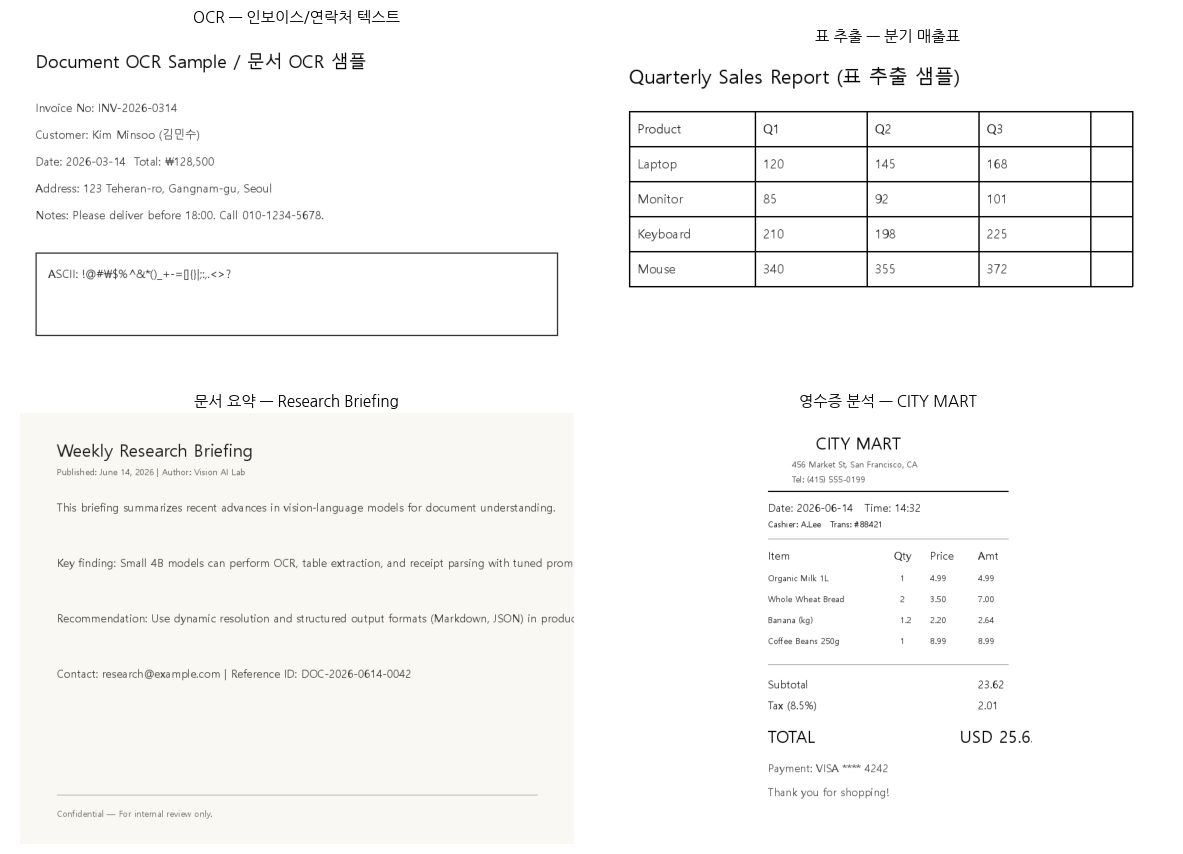

In [17]:
from pathlib import Path

# 로컬 샘플 이미지 디렉터리 (외부 URL 차단 대비)
SAMPLES_DIR = Path("samples/internvl")

SAMPLE_IMAGES = {
    "ocr": SAMPLES_DIR / "ocr.png",           # 인보이스 텍스트 — OCR
    "table": SAMPLES_DIR / "table.png",       # 분기 매출 표 — 표 추출
    "document": SAMPLES_DIR / "document.png", # 리서치 브리핑 — 문서 요약
    "receipt": SAMPLES_DIR / "receipt.png",   # 마트 영수증 — JSON 추출
}

SAMPLE_TITLES = {
    "ocr": "OCR — 인보이스/연락처 텍스트",
    "table": "표 추출 — 분기 매출표",
    "document": "문서 요약 — Research Briefing",
    "receipt": "영수증 분석 — CITY MART",
}

# 필수 샘플 PNG 존재 여부 확인
missing = [p for p in SAMPLE_IMAGES.values() if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "샘플 이미지가 없습니다. 노트북 상단 셀을 순서대로 실행했는지 확인하거나 "
        f"다음 경로에 PNG를 배치하세요:\n  {SAMPLES_DIR.resolve()}\n"
        f"누락: {[str(p) for p in missing]}"
    )

images = {name: Image.open(path).convert("RGB") for name, path in SAMPLE_IMAGES.items()}

print("로드된 샘플 이미지:")
for name, img in images.items():
    print(f"  {name:10s} size={img.size}  path={SAMPLE_IMAGES[name]}")

# 2×2 그리드 미리보기
show_all_samples(images, SAMPLE_TITLES)


## 5. 이미지 OCR

이미지에 포함된 **모든 텍스트**를 원문 그대로 추출합니다.
InternVL3.5는 OCRBench 등 OCR 벤치마크에서 높은 점수를 기록합니다.


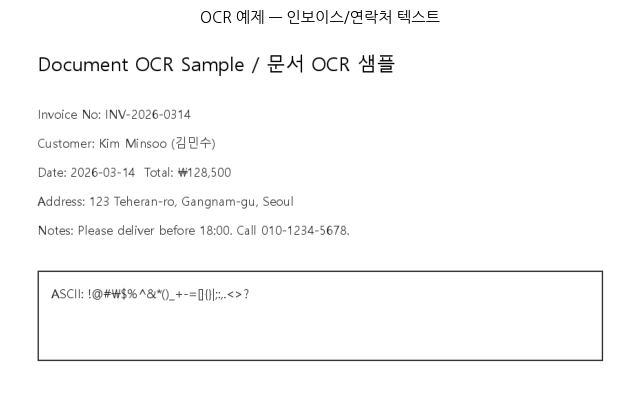

[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[OCR 결과]
Document OCR Sample / 문서 OCR 샘플

Invoice No: INV-2026-0314

Customer: Kim Minsoo (김민수)

Date: 2026-03-14 Total: ₩128,500

Address: 123 Tehran-ro, Gangnam-gu, Seoul

Notes: Please deliver before 18:00. Call 010-1234-5678.

ASCII: !@#$%^&*()_+=-[]{};:,.<>?


In [18]:
# OCR 예제 — 인보이스 샘플 이미지
ocr_image = images["ocr"]
show_image(ocr_image, "OCR 예제 — 인보이스/연락처 텍스트")

# 모델에 전달할 OCR 지시 프롬프트 (원문 그대로 추출 요청)
ocr_prompt = """이 이미지에 있는 모든 텍스트를 읽어서 원문 그대로 추출해 주세요.
- 줄바꿈과 단락 레이아웃을 최대한 유지하세요.
- 영문, 숫자, 기호를 빠짐없이 출력하세요.
- 설명 없이 추출된 텍스트만 출력하세요."""

ocr_result = ask_internvl(ocr_prompt, ocr_image, max_new_tokens=2048)
print("=" * 60)
print("[OCR 결과]")
print("=" * 60)
print(ocr_result)


## 6. 표 추출

이미지 속 **표(table)** 를 찾아 **Markdown 표** 형식으로 구조화합니다.
스프레드시트 스크린샷, PDF 표 캡처 등에 활용할 수 있습니다.


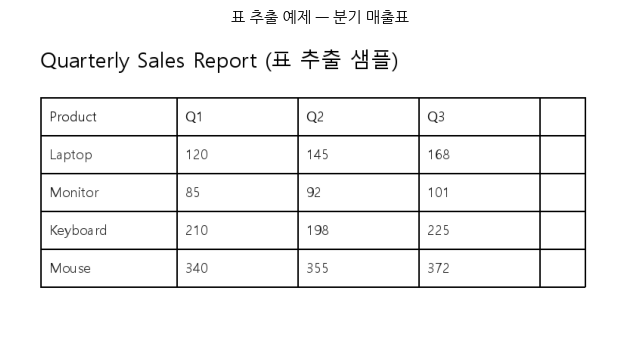

[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[표 추출 결과 — Markdown]
```markdown
| Product  | Q1  | Q2  | Q3  |
|----------|-----|-----|-----|
| Laptop   | 120 | 145 | 168 |
| Monitor  | 85  | 92  | 101 |
| Keyboard | 210 | 198 | 225 |
| Mouse    | 340 | 355 | 372 |

- 병합된 셀이 없음
```


In [19]:
# 표 추출 예제 — 분기 매출표 샘플
table_image = images["table"]
show_image(table_image, "표 추출 예제 — 분기 매출표")

# Markdown 표 형식으로 구조화하도록 지시
table_prompt = """이미지에서 표(table)를 찾아 Markdown 표 형식으로 추출해 주세요.
요구사항:
1. 헤더 행과 데이터 행을 구분하세요.
2. | 열1 | 열2 | 형식의 Markdown 표만 출력하세요.
3. 병합된 셀이 있으면 표 아래에 주석으로 설명하세요.
4. 표가 없으면 "표 없음"이라고만 답하세요."""

table_result = ask_internvl(table_prompt, table_image, max_new_tokens=1536)
print("=" * 60)
print("[표 추출 결과 — Markdown]")
print("=" * 60)
print(table_result)


## 7. 문서 요약

신문·보고서·계약서 등 **문서 이미지**의 핵심 내용을 한국어로 요약합니다.


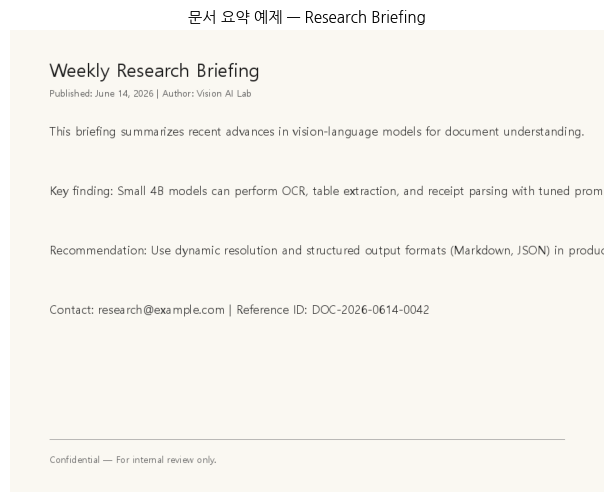

[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[문서 요약 결과]
## 문서 유형
 brief

## 핵심 요약
이 brief는 2026년 6월 14일에 Vision AI Lab에서 발행한 주간 연구 brief입니다. 이 brief는 문서 이해를 위한 비주얼-언어 모델의 최신 발전을 요약하고 있습니다. 주요 finding은 4B 소형 모델이 OCR, 표 추출, 영수증 파싱을 수행할 수 있다는 것입니다. 제안된 조치는 동적 해상도와 구조화된 출력 형식(Markdown, JSON)을 사용하는 것입니다.

## 주요 키워드
- 비주얼-언어 모델
- 문서 이해
- OCR
- 표 추출
- 영수증 파싱

## 중요 정보
- 발행일: 2026년 6월 14일
- 저자: Vision AI Lab
- Contact: research@example.com
- Reference ID: DOC-2026-0614-0042
- 소형 모델 용량: 4B


In [20]:
# 문서 요약 예제 — Research Briefing 샘플
doc_image = images["document"]
show_image(doc_image, "문서 요약 예제 — Research Briefing")

# 문서 유형·요약·키워드·중요 정보를 구조화해 답하도록 지시
summary_prompt = """이 문서 이미지의 내용을 한국어로 분석·요약해 주세요.
아래 형식으로 답변하세요:

## 문서 유형
(신문, 보고서, 계약서 등)

## 핵심 요약 (3~5문장)

## 주요 키워드
- 키워드 5개를 bullet로

## 중요 정보
- 날짜, 수치, 고유명사 등 눈에 띄는 사실을 bullet로"""

summary_result = ask_internvl(summary_prompt, doc_image, max_new_tokens=1536)
print("=" * 60)
print("[문서 요약 결과]")
print("=" * 60)
print(summary_result)


## 8. 영수증 분석

영수증 이미지에서 **상호, 날짜, 품목, 금액** 등을 JSON으로 구조화합니다.
경비 처리·회계 자동화 파이프라인의 1차 추출 단계로 사용할 수 있습니다.


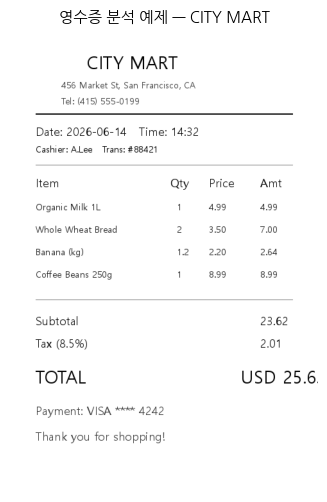

[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[영수증 분석 — 원본 응답]
{
  "store_name": "CITY MART",
  "address": "456 Market St, San Francisco, CA",
  "date": "2026-06-14",
  "time": "14:32",
  "items": [
    {"name": "Organic Milk 1L", "qty": 1, "unit_price": 4.99, "amount": 4.99},
    {"name": "Whole Wheat Bread", "qty": 2, "unit_price": 3.50, "amount": 7.00},
    {"name": "Banana (kg)", "qty": 1.2, "unit_price": 2.20, "amount": 2.64},
    {"name": "Coffee Beans 250g", "qty": 1, "unit_price": 8.99, "amount": 8.99}
  ],
  "subtotal": 23.62,
  "tax": 2.01,
  "total": 25.63,
  "payment_method": "VISA",
  "currency": "USD"
}

[영수증 분석 — 파싱된 JSON]
{
  "store_name": "CITY MART",
  "address": "456 Market St, San Francisco, CA",
  "date": "2026-06-14",
  "time": "14:32",
  "items": [
    {
      "name": "Organic Milk 1L",
      "qty": 1,
      "unit_price": 4.99,
      "amount": 4.99
    },
    {
      "name": "Whole Wheat Bread",
      "qty": 2,
      "unit_price": 3.5,
      "amount": 7.0
    },
    {
      "name": "Banana (kg)",
      "qty"

In [21]:
# 영수증 분석 예제 — CITY MART 샘플
receipt_image = images["receipt"]
show_image(receipt_image, "영수증 분석 예제 — CITY MART")

# JSON 스키마를 프롬프트에 명시해 구조화된 출력 유도
receipt_prompt = """이 영수증 이미지를 분석하여 아래 JSON 형식으로 추출해 주세요.
읽을 수 없는 필드는 null로 두고, JSON만 출력하세요 (코드 블록 없이).

{
  "store_name": "",
  "address": "",
  "date": "",
  "time": "",
  "items": [
    {"name": "", "qty": 0, "unit_price": 0, "amount": 0}
  ],
  "subtotal": null,
  "tax": null,
  "total": null,
  "payment_method": "",
  "currency": ""
}"""

receipt_raw = ask_internvl(receipt_prompt, receipt_image, max_new_tokens=1536)
print("=" * 60)
print("[영수증 분석 — 원본 응답]")
print("=" * 60)
print(receipt_raw)

# JSON 파싱 시도 (모델이 마크다운 코드블록을 붙인 경우 대비)
text = receipt_raw.strip()
if text.startswith("```"):
    lines = text.splitlines()
    text = "\n".join(lines[1:-1] if lines[-1].strip() == "```" else lines[1:])

try:
    receipt_json = json.loads(text)
    print("\n" + "=" * 60)
    print("[영수증 분석 — 파싱된 JSON]")
    print("=" * 60)
    print(json.dumps(receipt_json, ensure_ascii=False, indent=2))
except json.JSONDecodeError as exc:
    print(f"\nJSON 파싱 실패 ({exc}). 프롬프트에 'JSON만 출력'을 강조하거나 temperature=0으로 재시도하세요.")


## 9. 한국어 OCR — 로컬 이미지

한국어 문서·간판·메뉴판 등 **로컬 이미지**로 OCR을 테스트하려면 아래 셀의 경로를 수정하세요.


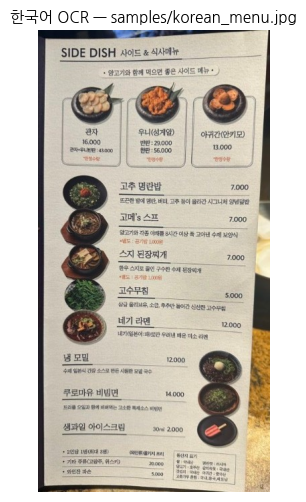

[transformers] Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


SIDE DISH 사이드 & 식사메뉴

• 양고기와 함께 먹으면 좋은 사이드 메뉴 •

광자 16,000
(광자+비프) 43,000
(선택사항)

우니(순계) 29,000
(반) 56,000
(반) (선택사항)

아귀간(안키모) 13,000

고추 멸량밥 7,000
(또한 밥에 덜어, 비터, 고추 등이 들어간 시그니처 완성)

고메' s 스프 7,000
(양고기와 감자, 야채가 8가지 이상 콩과 비누 보완식)

스지 된장찌개 7,000
(합은 스치다로 품구분 수저 팬참여)

고수무침 5,000
(상추, 올리브, 소고기, 후추, 놀이감 산간한 고수무침)

네가 라면 12,000
(네가일어남-프로모우션 후레나 레인 미소 라면)

냉 모밀 12,000
(수제 흰강식감 소스로 만든 시원한 모밀粥)

쿠로마유 비빔면 14,000
(프로세스 오염과 함께 비대해고소한 퓩치다 소비빔면)

생과일 아이스크림 30ml 2,000

• 2인분 (베이스) (베이스)

여러분의 선호에 맞춘 프리
(베이스) 20,000
(선택사항)

아이스크림 5,000


In [22]:
# 로컬 한국어 이미지 경로 (None이면 이 예제는 건너뜀)
LOCAL_KO_IMAGE = "samples/korean_menu.jpg"

if LOCAL_KO_IMAGE:
    ko_image = Image.open(LOCAL_KO_IMAGE).convert("RGB")
    show_image(ko_image, f"한국어 OCR — {LOCAL_KO_IMAGE}")

    ko_ocr_prompt = (
        "이 이미지의 모든 한국어·영어·숫자 텍스트를 원문 그대로 추출해 주세요.\n"
        "레이아웃(줄바꿈)을 유지하고, 설명 없이 텍스트만 출력하세요."
    )

    ko_result = ask_internvl(ko_ocr_prompt, ko_image, max_new_tokens=2048)
    print(ko_result)
else:
    print("LOCAL_KO_IMAGE 경로를 설정하면 한국어 OCR 예제를 실행합니다.")


## 10. 정리 & Qwen3-VL과 비교

| 항목 | InternVL3.5-4B-HF | Qwen3-VL-4B (`06` 노트북) |
|------|-------------------|---------------------------|
| 로드 방식 | `AutoModelForImageTextToText` + `AutoProcessor` | `Qwen3VLForConditionalGeneration` |
| 이미지 전처리 | Processor 내장 (동적 해상도) | Processor 내장 |
| 대화 API | `apply_chat_template()` + `generate()` | `apply_chat_template()` |
| OCR/문서 | OCRBench SOTA급, 표·문서 특화 프롬프트 | 32개 언어 OCR, chat 형식 |
| VRAM | ~10~12GB (4B) | ~8~10GB (4B) |

### 실무 팁
- **GitHub 포맷(`InternVL3_5-4B`)**: transformers 5.x에서는 `all_tied_weights_keys` 오류 가능 → **HF 포맷** 사용 권장.
- **JSON 출력 안정화**: `do_sample=False`, 프롬프트에 "JSON만 출력"을 명시하세요.
- **Thinking 모드**: 복잡한 추론이 필요하면 모델 카드의 `R1_SYSTEM_PROMPT`를 system 메시지에 추가하세요.

### 다음 단계
- 자사 영수증·계약서 샘플로 프롬프트 튜닝
- 표 추출 결과를 pandas DataFrame으로 변환
- `06_qwen3_vl_example.ipynb`와 동일 이미지로 OCR 품질 비교
